In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Exploratory Data Analysis (EDA):

In [4]:
data = pd.read_excel('glass.xlsx',sheet_name= 1)

In [5]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
data.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [8]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


### Data Visualization:

#### Histogram :

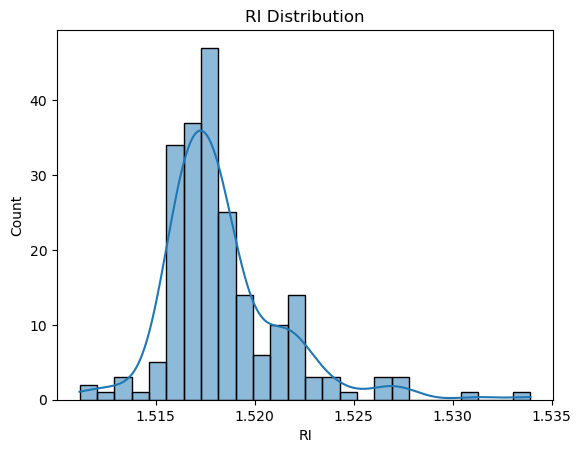

RI Skewness : 1.6254305060087644


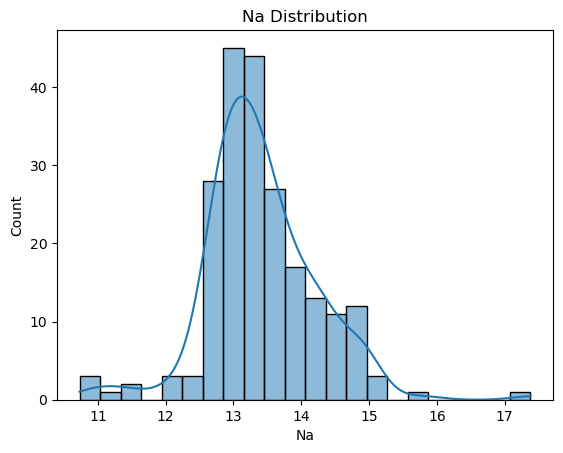

Na Skewness : 0.4541814536577495


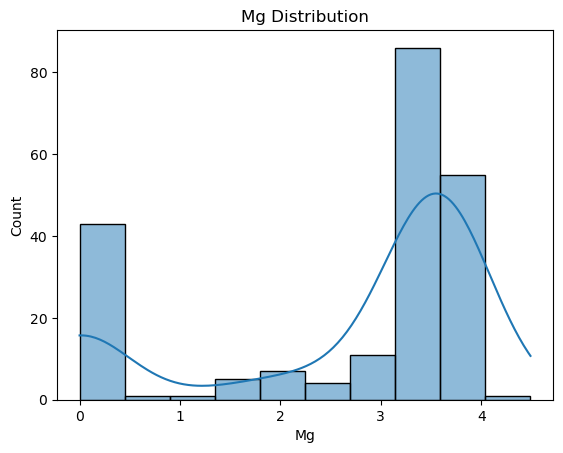

Mg Skewness : -1.1525593175802356


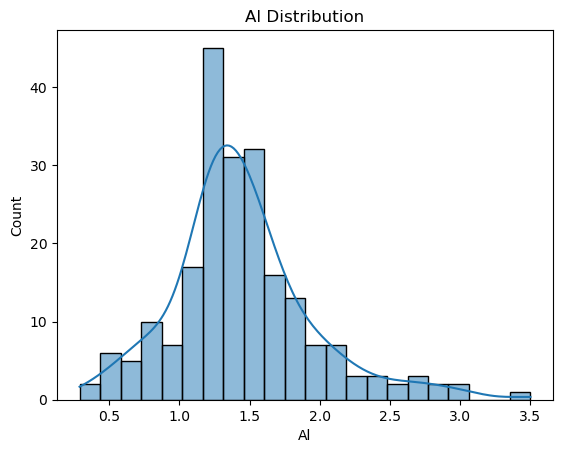

Al Skewness : 0.9072898090246346


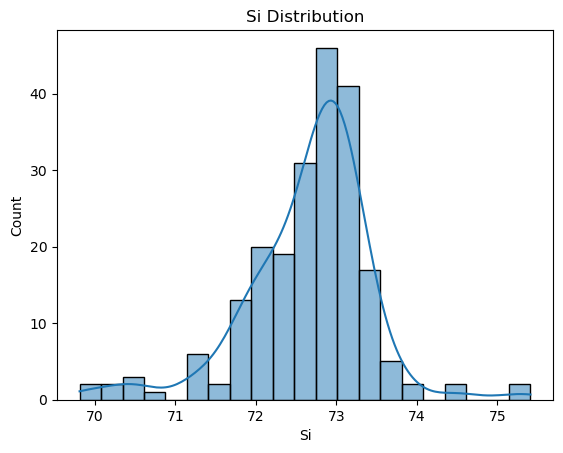

Si Skewness : -0.7304472251318588


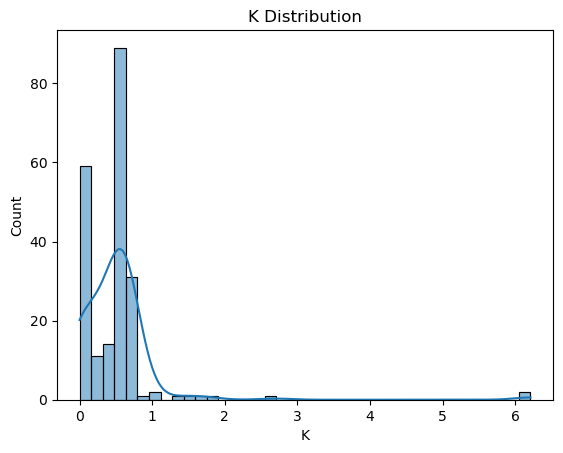

K Skewness : 6.55164830960496


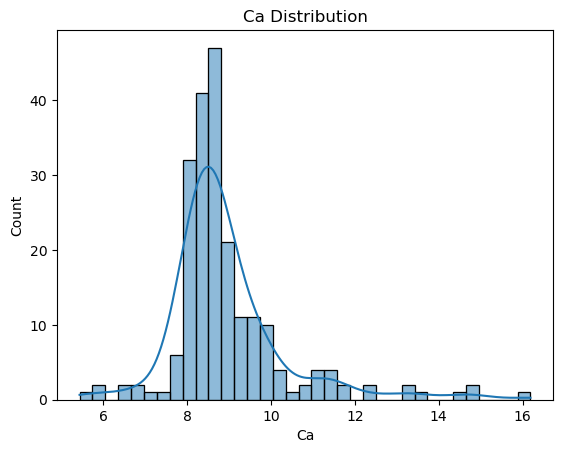

Ca Skewness : 2.0470539131183103


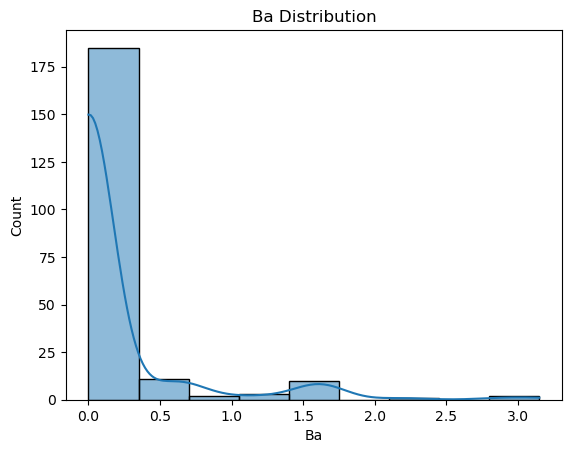

Ba Skewness : 3.4164245693025577


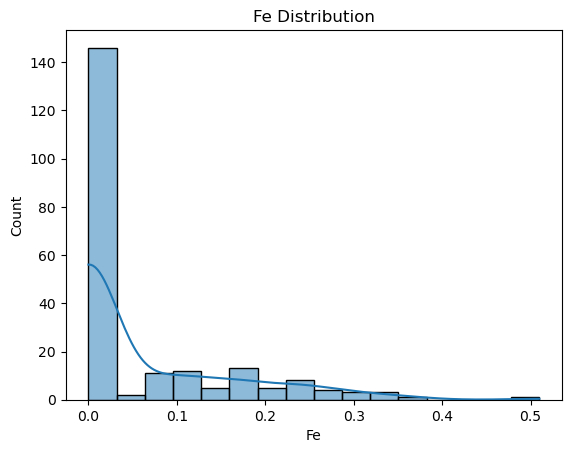

Fe Skewness : 1.754327470435831


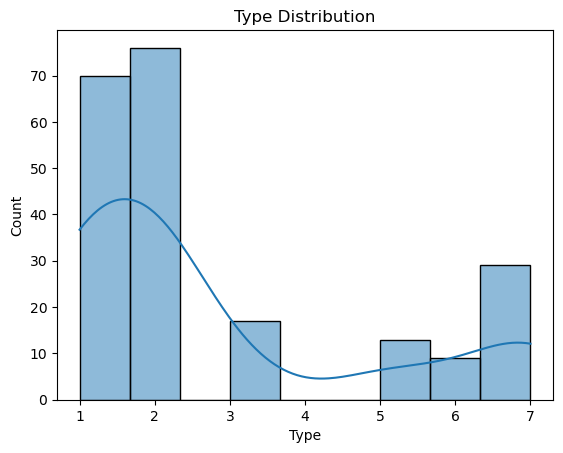

Type Skewness : 1.114915200905486


In [10]:
for col in data.columns:
    sns.histplot(data[col],kde=True)
    plt.title(f'{col} Distribution')
    plt.show()
    print(f'{col} Skewness :', data[col].skew())

In [11]:
for col in data.columns:
    print(f'{col} Skewness :', data[col].skew())

RI Skewness : 1.6254305060087644
Na Skewness : 0.4541814536577495
Mg Skewness : -1.1525593175802356
Al Skewness : 0.9072898090246346
Si Skewness : -0.7304472251318588
K Skewness : 6.55164830960496
Ca Skewness : 2.0470539131183103
Ba Skewness : 3.4164245693025577
Fe Skewness : 1.754327470435831
Type Skewness : 1.114915200905486


#### - Positively skewed features: RI, Na, Al, K, Ca, Ba, Fe, Type
####  Data is concentrated on the left with a long tail on the right.
#### - Negatively skewed features: Mg, Si
####   Data is concentrated on the right with a long tail on the left.
#### - Most skewed feature:
####   K (Potassium) → Extremely skewed, may need transformation.

#### Boxplot with outliers :

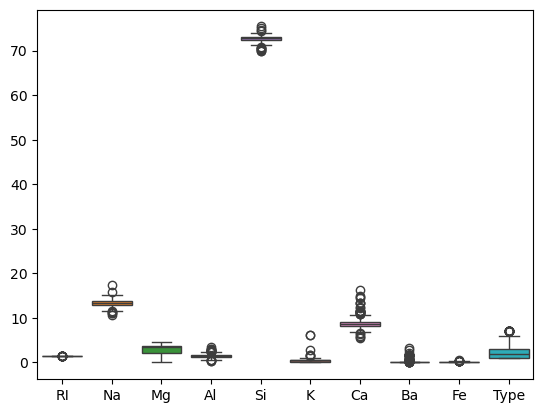

In [12]:
sns.boxplot(data)
plt.show()

In [14]:
for col in data.columns:
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    outliers =  data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'{col} outliers :', outliers.shape[0])

RI outliers : 17
Na outliers : 7
Mg outliers : 0
Al outliers : 18
Si outliers : 12
K outliers : 7
Ca outliers : 26
Ba outliers : 38
Fe outliers : 12
Type outliers : 29


In [15]:
for col in data.columns:
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    data[col] = data[col].clip(upper_bound, lower_bound)

#### Boxplot after cleaning outliers :

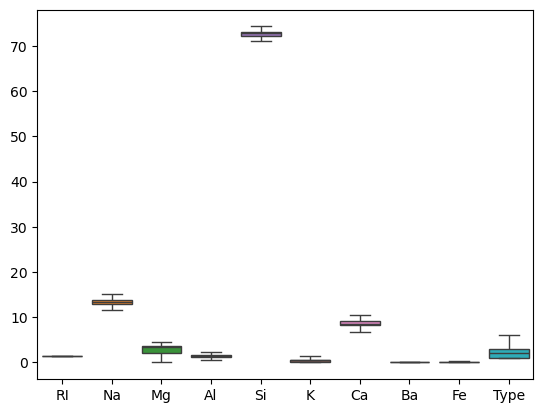

In [17]:
sns.boxplot(data)
plt.show()

#### After replaced outliers with upper bound and lower bound we can see that the boxplot is cleaned now.

#### Corelation Heatmap :

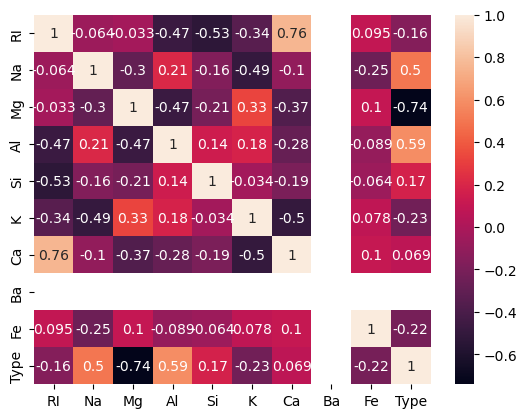

In [21]:
sns.heatmap(data.corr(),annot=True)
plt.show()

### 2. Data Preprocessing :

#### Label Encoding :

#### All Data is numeric soo need of Label Encoding Or One-Hot Encoding:

#### Feature Scaling :

In [22]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
scaler.fit_transform(data)

array([[ 1.20149683,  0.31687123,  1.25463857, ...,  0.        ,
        -0.61909102, -0.89487798],
       [-0.23426899,  0.65422823,  0.63616803, ...,  0.        ,
        -0.61909102, -0.89487798],
       [-0.83813521,  0.16843415,  0.60142249, ...,  0.        ,
        -0.61909102, -0.89487798],
       ...,
       [ 1.04947457,  1.28845939, -1.86551055, ...,  0.        ,
        -0.61909102,  1.8253477 ],
       [-0.69878146,  1.31544795, -1.86551055, ...,  0.        ,
        -0.61909102,  1.8253477 ],
       [-0.44541102,  1.11303375, -1.86551055, ...,  0.        ,
        -0.61909102,  1.8253477 ]])

#### 3 : Random Forest Model Implementation

#### Split the data :

In [25]:
from sklearn.model_selection import train_test_split

In [27]:
X = data.drop('Type',axis=1)
y = data['Type']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
X_train.shape, X_test.shape ,y_train.shape, y_test.shape

((171, 9), (43, 9), (171,), (43,))

#### Model Building :

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

#### Model Evaluation :

##### Predicting :

In [32]:
y_pred = rf.predict(X_test)

##### Evaluate Model :

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.813953488372093

Confusion Matrix:
 [[11  0  0  0  0]
 [ 4  9  0  0  1]
 [ 1  0  2  0  0]
 [ 0  2  0  2  0]
 [ 0  0  0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.82      0.64      0.72        14
           3       1.00      0.67      0.80         3
           5       1.00      0.50      0.67         4
           6       0.92      1.00      0.96        11

    accuracy                           0.81        43
   macro avg       0.88      0.76      0.79        43
weighted avg       0.84      0.81      0.81        43



### 4. Bagging and Boosting Methods :

#### Bagging Model :

In [37]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

In [38]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=400)
bag_model = BaggingClassifier(estimator=logreg, n_estimators=100)

In [40]:
bag_model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

BaggingClassifier(estimator=LogisticRegression(max_iter=400), n_estimators=100)

In [41]:
yhat_train = bag_model.predict(X_train)

In [42]:
cm = confusion_matrix(y_train,yhat_train)
cm

array([[47, 12,  0,  0,  0],
       [18, 39,  0,  2,  3],
       [ 9,  5,  0,  0,  0],
       [ 0,  5,  0,  2,  2],
       [ 1,  4,  0,  1, 21]])

In [43]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           1       0.63      0.80      0.70        59
           2       0.60      0.63      0.61        62
           3       0.00      0.00      0.00        14
           5       0.40      0.22      0.29         9
           6       0.81      0.78      0.79        27

    accuracy                           0.64       171
   macro avg       0.49      0.49      0.48       171
weighted avg       0.58      0.64      0.60       171



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Boosting Model :

In [44]:
ada_model = AdaBoostClassifier(n_estimators=100)
ada_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100)

In [45]:
yhat_train = ada_model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
print(cm)
print(classification_report(y_train, yhat_train))

[[55  4  0  0  0]
 [45 16  0  0  1]
 [14  0  0  0  0]
 [ 0  8  0  0  1]
 [ 1  4  0  0 22]]
              precision    recall  f1-score   support

           1       0.48      0.93      0.63        59
           2       0.50      0.26      0.34        62
           3       0.00      0.00      0.00        14
           5       0.00      0.00      0.00         9
           6       0.92      0.81      0.86        27

    accuracy                           0.54       171
   macro avg       0.38      0.40      0.37       171
weighted avg       0.49      0.54      0.48       171



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Overall Accuracy
##### Bagging (Random Forest) → 0.64
##### Boosting (AdaBoost) → 0.54
##### Bagging performs better in overall accuracy

#### 1. Explain Bagging and Boosting methods. How is it different from each other.

#### - Bagging and Boosting are ensemble learning techniques used to improve model performance. 
#### - Bagging reduces variance by training multiple models independently, while Boosting reduces bias by training models sequentially and focusing on previous errors.
#### - Bagging is more stable, whereas Boosting can achieve higher accuracy but is sensitive to noise.

#### 2. Explain how to handle imbalance in the data.

#### - Imbalanced data occurs when some classes have significantly fewer samples than others, which can lead to biased model performance.
#### - To handle imbalance, techniques such as oversampling (e.g., SMOTE), undersampling, and class weighting can be used.
#### - Additionally, evaluation metrics like precision, recall, and F1-score should be preferred over accuracy.
#### - These methods help improve the model’s ability to correctly predict minority classes.